In [3]:
# Import libraries
import ast                                 # Convert string representations of lists into real Python lists
import pandas as pd                        # Data analysis library
from datasets import load_dataset          # Load Luke's dataset from Hugging Face
import matplotlib.pyplot as plt            # Plotting library

# Load dataset
dataset = load_dataset('lukebarousse/data_jobs')   # Download the dataset
df = dataset['train'].to_pandas()                  # Convert it into a Pandas DataFrame

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])   # Convert dates from strings to datetime objects

# Convert the 'job_skills' column from strings into real Python lists
# (explode() only works correctly if each cell contains an actual list)
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x   # Convert if not NaN, otherwise leave missing values unchanged
)

<Axes: xlabel='job_skills'>

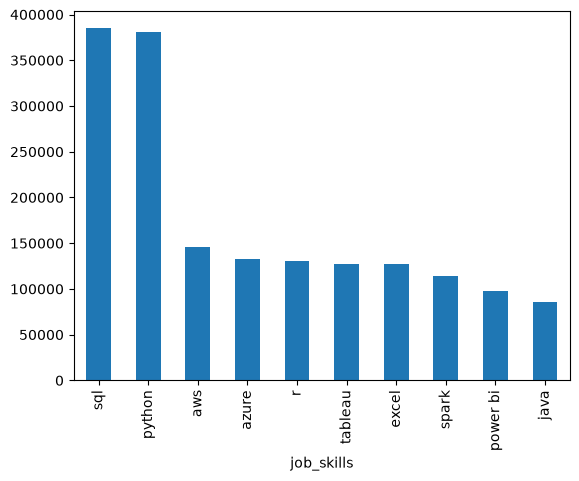

In [7]:
# Split each list of skills into separate rows
df_exploded = df.explode('job_skills')      # One skill per row

# Count the most common skills and plot them
(
    df_exploded['job_skills']               # Select the job_skills column
        .value_counts()                     # Count each unique skill
        .head(10)                           # Keep only the top 10 skills
        .plot(kind='bar')                   # Plot a vertical bar chart
)

In [9]:
# Explode the list of skills so each skill gets its own row
df_exploded = df.explode('job_skills')

# Count how many times each skill appears for each job title
df_skills_count = (
    df_exploded
    .groupby(['job_title_short', 'job_skills'])   # Group by job title and skill
    .size()                                       # Count rows in each group
    .reset_index(name='skill_count')              # Convert counts into a DataFrame
    .sort_values('skill_count', ascending=False)  # Highest counts first
)

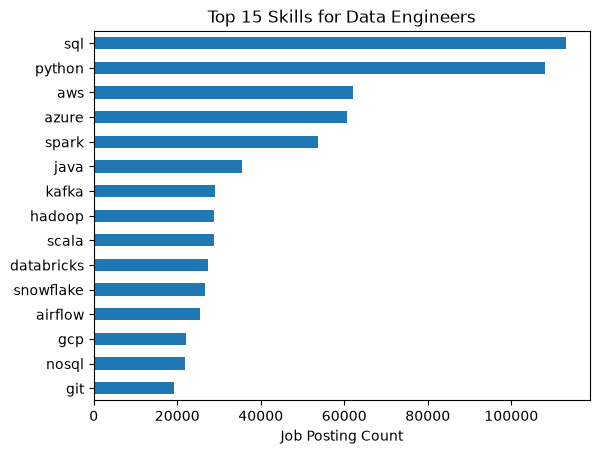

In [11]:
# Choose which job title to analyze
job_title = 'Data Engineer'                # Job title to filter for
top_skills = 15                            # Number of top skills to display

# Keep only this job title and the top N skills
df_skill_final = (
    df_skills_count[
        df_skills_count['job_title_short'] == job_title   # Filter rows
    ].head(top_skills)                                    # First 15 skills
)

# Create a horizontal bar chart
df_skill_final.plot(
    kind='barh',                      # Horizontal bar chart
    x='job_skills',                   # Skill names on the y-axis
    y='skill_count'                   # Counts determine bar length
)

# ----- Customize the chart -----

plt.gca().invert_yaxis()                           # Put the highest-ranked skill at the top
plt.title(f'Top {top_skills} Skills for {job_title}s')  # Dynamic chart title
plt.xlabel('Job Posting Count')                    # Label the x-axis
plt.ylabel('')                                     # Hide the y-axis label (cleaner look)
plt.legend().set_visible(False)                    # Hide the legend (only one data series)